In [1]:
import pandas as pd
import os
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

In [2]:
# customizing 'markdown' font style
from IPython.display import display, HTML

display(HTML("""
<style>
.jp-RenderedMarkdown{
    color: red !important;
    font-size: 28px !important;
    font-weight: 700 !important;
}
</style>
"""))

In [3]:
# enable all row display
# pd.set_option('display.max_rows', None)

In [4]:
all_dfs = []
sales_data_dir = './scraped_auto_punditz_sales_data'
for file in os.listdir(sales_data_dir):
    # print('CURRENT FILE:', file)
    all_dfs.append(pd.read_csv(os.path.join(sales_data_dir, file)))
df = pd.concat(all_dfs, ignore_index = True)
print('All dfs combined')

All dfs combined


In [5]:
# saving it as 
df.to_csv('sales_data_combined.csv')

In [6]:
df.head()

,date,company,model,monthly_sales,total_sales
0,Jun-20,Fiat,COMPASS,246.0,246.0
1,Jun-20,Fiat,WRANGLER,10.0,10.0
2,Jun-20,Ford,Figo,174.0,174.0
3,Jun-20,Ford,FREESTYLE,506.0,506.0
4,Jun-20,Ford,Aspire,381.0,381.0


In [7]:
df.describe()

,date,company,model,monthly_sales,total_sales
count,5586,5586,5586,5586,5586
unique,71,16,151,960,960
top,Oct-19,Maruti,COMPASS,1.5K,1.5K
freq,91,1055,71,82,82


In [8]:
df.isna().sum()

date             0
company          0
model            0
monthly_sales    0
total_sales      0
dtype: int64

In [9]:
df.company.unique()

array(['Fiat', 'Ford', 'Honda', 'Hyundai', 'Kia', 'Mahindra', 'Maruti',
       'Morris Garage', 'Nissan', 'Renault', 'Skoda', 'Tata', 'Toyota',
       'Volkswagen', 'Grand Total', 'Citroen'], dtype=object)

In [10]:
for company, company_df in df.groupby('company'):
    print('COMPANY_NAME:', company)
    print(df.loc[df['company'] == company]['model'].unique().tolist(), '\n')

COMPANY_NAME: Citroen
['C3', 'Ë C3', 'C3 Aircross', 'Basalt', 'C5 Aircross'] 

COMPANY_NAME: Fiat
['COMPASS', 'WRANGLER', 'Meridian', 'Linea', 'Grand Cherokee', 'Punto + Evo + Avventura', 'Abarth'] 

COMPANY_NAME: Ford
['Figo', 'FREESTYLE', 'Aspire', 'Ecosport', 'Endeavour', 'Mustang'] 

COMPANY_NAME: Grand Total
['Grand Total'] 

COMPANY_NAME: Honda
['Amaze', 'City', 'WRV', 'Civic', 'CR-V', 'ELEVATE', 'Jazz', 'BR-V'] 

COMPANY_NAME: Hyundai
['Santro', 'Grand i10', 'i20 Elite', 'Xcent/Aura', 'Venue', 'Creta', 'Verna', 'Elantra', 'Tucson', 'KONA', 'EXTER', 'ALCAZAR', 'IONIQ 5'] 

COMPANY_NAME: Kia
['SELTOS', 'CARNIVAL', 'SONET', 'CARENS', 'SYROS', 'EV6', 'EV9'] 

COMPANY_NAME: Mahindra
['Verito', 'KUV 100', 'Bolero', 'XUV 300', 'Scorpio', 'XUV 500', 'XUV 700', 'Thar', 'XUV 400', 'BE6', 'XE 9e', 'Marazzo', 'Alturas G4', 'Xylo', 'TUV 300', 'BE 6', 'XEV 9e', 'NuvoSport'] 

COMPANY_NAME: Maruti
['Alto', 'Eeco', 'S Presso', 'Wagon R', 'IGNIS', 'Ertiga', 'XL6', 'CELERIO', 'Vitara Brezza', 'Sw

In [11]:
df.apply(lambda col: print(col.name, '-', col.dtype))

date - object
company - object
model - object
monthly_sales - object
total_sales - object


date             None
company          None
model            None
monthly_sales    None
total_sales      None
dtype: object

In [12]:
df = df.apply(lambda col: col.str.upper() if col.name in ['company', 'model'] else col)

In [13]:
model_name_corrected = np.array([
    ["Mahindra", "BE6", "BE 6"],
    ["Mahindra", "XE 9e", "XEV 9e"],
    ["Tata", "Safari+Storme", "Safari Storme"],
    ["Toyota", "Innova + Hycross", "Innova"]
])

In [14]:
for car_details in model_name_corrected:
    df.loc[(df['company'] == car_details[0]) & (df['model'] == car_details[1]), 'model'] = str(car_details[2])

In [15]:
df.loc[(df['company'] == 'Fiat') & ((df['model'] == 'WRANGLER') | (df['model'] == 'Meridian') | (df['model'] == 'COMPASS') | (df['model'] == 'Grand Cherokee')), 'company'] = 'Jeep'

In [16]:
# again printing the company names and model names
for company, company_df in df.groupby('company'):
    print('COMPANY_NAME:', company)
    print(df.loc[df['company'] == company]['model'].unique().tolist(), '\n')

COMPANY_NAME: CITROEN
['C3', 'Ë C3', 'C3 AIRCROSS', 'BASALT', 'C5 AIRCROSS'] 

COMPANY_NAME: FIAT
['COMPASS', 'WRANGLER', 'MERIDIAN', 'LINEA', 'GRAND CHEROKEE', 'PUNTO + EVO + AVVENTURA', 'ABARTH'] 

COMPANY_NAME: FORD
['FIGO', 'FREESTYLE', 'ASPIRE', 'ECOSPORT', 'ENDEAVOUR', 'MUSTANG'] 

COMPANY_NAME: GRAND TOTAL
['GRAND TOTAL'] 

COMPANY_NAME: HONDA
['AMAZE', 'CITY', 'WRV', 'CIVIC', 'CR-V', 'ELEVATE', 'JAZZ', 'BR-V'] 

COMPANY_NAME: HYUNDAI
['SANTRO', 'GRAND I10', 'I20 ELITE', 'XCENT/AURA', 'VENUE', 'CRETA', 'VERNA', 'ELANTRA', 'TUCSON', 'KONA', 'EXTER', 'ALCAZAR', 'IONIQ 5'] 

COMPANY_NAME: KIA
['SELTOS', 'CARNIVAL', 'SONET', 'CARENS', 'SYROS', 'EV6', 'EV9'] 

COMPANY_NAME: MAHINDRA
['VERITO', 'KUV 100', 'BOLERO', 'XUV 300', 'SCORPIO', 'XUV 500', 'XUV 700', 'THAR', 'XUV 400', 'BE6', 'XE 9E', 'MARAZZO', 'ALTURAS G4', 'XYLO', 'TUV 300', 'BE 6', 'XEV 9E', 'NUVOSPORT'] 

COMPANY_NAME: MARUTI
['ALTO', 'EECO', 'S PRESSO', 'WAGON R', 'IGNIS', 'ERTIGA', 'XL6', 'CELERIO', 'VITARA BREZZA', 'SW

In [17]:
target_vehicles = {
    "CITROEN": ['C3', 'Ë C3', 'C3 Aircross', 'Basalt', 'C5 Aircross'], 
    "FORD": ['ECOSPORT', 'ENDEAVOUR'],
    "HONDA": ['WRV', 'CR-V', 'ELEVATE', 'BR-V'],
    "HYUNDAI": ['VENUE', 'CRETA', 'TUCSON', 'KONA', 'EXTER', 'ALCAZAR', 'IONIQ 5'],
    "JEEP": ['COMPASS', 'WRANGLER', 'MERIDIAN', 'GRAND CHEROKEE'],
    "KIA": ['SELTOS', 'CARNIVAL', 'SONET', 'CARENS', 'SYROS', 'EV6', 'EV9'],
    "MAHINDRA" : ['KUV 100', 'BOLERO', 'XUV 300', 'SCORPIO', 'XUV 500', 'XUV 700', 'THAR', 'XUV 400', 'BE 6', 'XEV 9E', 'MARAZZO', 'ALTURAS G4', 'XYLO', 'TUV 300', 'NUVOSPORT'],
    "MARUTI" : ['S PRESSO', 'ERTIGA', 'XL6','VITARA BREZZA', 'GYPSY', 'FRONX', 'JIMNY', 'INVICTO', 'GRAND VITARA', 'S-CROSS'],
    "MORRIS GARAGE" : ['HECTOR', 'ZS EV', 'GLOSTER', 'ASTOR'],
    "NISSAN" : ['GO+', 'KICKS', 'MAGNITE', 'TERRANO', 'X-TRAIL'],
    "RENAULT" : ['TRIBER', 'DUSTER', 'KIGER', 'LODGY', 'CAPTUR'],
    "SKODA" : ['KAROQ', 'KYLAQ', 'KUSHAQ', 'KODIAQ'], 
    "TATA" : ['NEXON', 'HARRIER', 'PUNCH', 'SAFARI', 'CURVV', 'SAFARI STORME', 'HEXA'],
    "TOYOTA" : ['INNOVA', 'FORTUNER', 'TAISOR', 'RUMION', 'HYRYDER', 'PRADO', 'LANDCRUISER', 'URBAN CRUISER'],
    "VOLKSWAGEN" : ['TAIGUN', 'TIGUAN', 'T-ROC']
}

In [18]:
# new empty df with same structure
dftv = pd.DataFrame(columns = df.columns.tolist())

In [19]:
for company in target_vehicles.keys():
    for model in target_vehicles[company]:
        dftv = pd.concat([dftv, df.loc[(df['company'] == company) & (df['model'] == model)]], ignore_index = True)    

In [20]:
# dropping 'monthly_sales' column
dftv.drop('monthly_sales', axis=1, inplace=True)

In [21]:
dftv.rename(columns={'total_sales': 'sales'}, inplace=True)

In [22]:
dftv.describe()

,date,company,model,sales
count,2938,2938,2938,2938
unique,71,14,81,697
top,Mar-25,MAHINDRA,VITARA BREZZA,2.1K
freq,55,541,71,55


In [23]:
dftv.head()

,date,company,model,sales
0,Jan-25,CITROEN,C3,242.0
1,Mar-25,CITROEN,C3,120.0
2,Mar-24,CITROEN,C3,265.0
3,Jul-24,CITROEN,C3,90.0
4,Jan-24,CITROEN,C3,234.0


In [24]:
dftv.to_csv('target_vehicles.csv')

In [25]:
# checking the data types of each row
dftv.apply(lambda col: print(col.name, '-', col.dtype))

date - object
company - object
model - object
sales - object


date       None
company    None
model      None
sales      None
dtype: object

In [26]:
dftv['sales_temp'] = dftv['sales'][dftv['sales'].str.contains('K', na = False)]

In [27]:
# dftv['temp_sales'] = dftv[dftv['sales'].str.contains('K', regex = False)]
dftv.describe()

,date,company,model,sales,sales_temp
count,2938,2938,2938,2938,1806
unique,71,14,81,697,174
top,Mar-25,MAHINDRA,VITARA BREZZA,2.1K,2.1K
freq,55,541,71,55,55


In [28]:
dftv['sales_temp'].unique()

array([nan, '1.1K', '1.2K', '1.4K', '3.1K', '3.5K', '3.3K', '3.9K',
       '2.4K', '2.2K', '5.5K', '1.6K', '2.3K', '2.8K', '3.8K', '3.2K',
       '4.3K', '3.7K', '1.7K', '4.6K', '3.6K', '2.9K', '1.0K', '1.3K',
       '1.5K', '1.8K', '2.5K', '4.8K', '2.1K', '5.0K', '4.4K', '2.0K',
       '5.7K', '4.1K', '11.1K', '9.6K', '10.4K', '8.8K', '11.8K', '4.9K',
       '11.6K', '10.3K', '10.7K', '10.1K', '10.0K', '9.2K', '12.0K',
       '11.4K', '6.7K', '6.1K', '8.2K', '9.9K', '9.7K', '9.8K', '9.3K',
       '7.9K', '11.2K', '10.9K', '8.6K', '8.4K', '10.2K', '9.5K', '12.3K',
       '9.1K', '8.9K', '10.6K', '8.3K', '7.0K', '12.2K', '11.0K', '8.5K',
       '7.2K', '18.5K', '6.6K', '18.1K', '16.5K', '17.4K', '13.2K',
       '14.4K', '13.8K', '15.0K', '14.1K', '14.0K', '10.5K', '12.6K',
       '6.9K', '11.5K', '13.0K', '16.3K', '15.5K', '13.3K', '12.5K',
       '12.4K', '17.5K', '7.3K', '12.7K', '14.2K', '11.9K', '7.6K',
       '13.1K', '15.4K', '15.3K', '6.5K', '15.9K', '14.7K', '6.0K',
       '16.8

In [29]:
dftv.head()

,date,company,model,sales,sales_temp
0,Jan-25,CITROEN,C3,242.0,NaN
1,Mar-25,CITROEN,C3,120.0,NaN
2,Mar-24,CITROEN,C3,265.0,NaN
3,Jul-24,CITROEN,C3,90.0,NaN
4,Jan-24,CITROEN,C3,234.0,NaN


In [30]:
dftv['sales_temp'] = dftv['sales_temp'].str.replace('K', '', regex=False)

In [31]:
dftv['sales_temp'] = dftv['sales_temp'].astype('float')

In [32]:
dftv['sales_temp'] = dftv['sales_temp'] * 1000

In [33]:
dftv.loc[(dftv['sales_temp'].notna()), 'sales'] = dftv['sales_temp']

In [34]:
dftv['sales'].str.contains('K', regex = False).unique()

array([False, nan], dtype=object)

In [35]:
# dftv.to_csv('temp_dataset.csv')

In [36]:
dftv.isna().sum()

date             0
company          0
model            0
sales            0
sales_temp    1132
dtype: int64

In [37]:
dftv['sales'] = dftv['sales'].astype(float)

In [38]:
dftv.apply(lambda col: print(col.name, '-', col.dtype))

date - object
company - object
model - object
sales - float64
sales_temp - float64


date          None
company       None
model         None
sales         None
sales_temp    None
dtype: object

In [39]:
dftv.groupby('company')['sales'].sum()

company
CITROEN            19304.0
FORD               93184.0
HONDA              91613.0
HYUNDAI          1741056.0
KIA              1198166.0
MAHINDRA         1921939.0
MARUTI           2782075.0
MORRIS GARAGE     225738.0
NISSAN            144280.0
RENAULT           279794.0
SKODA             106025.0
TATA             1548794.0
TOYOTA            399997.0
VOLKSWAGEN         87385.0
Name: sales, dtype: float64

In [40]:
# converting 'date' column data type into 'datetime64[ns]' 
# pd.to_datetime(df['date'], format='%m-%Y')
dftv['date'] = pd.to_datetime(dftv['date'], format='%b-%y')

In [41]:
dftv = dftv.sort_values(by='date', ascending=True)

In [42]:
dftv.head()

,date,company,model,sales,sales_temp
2268,2019-04-01,RENAULT,LODGY,46.0,NaN
959,2019-04-01,MAHINDRA,XUV 300,4200.0,4200.0
2700,2019-04-01,TOYOTA,FORTUNER,1500.0,1500.0
2382,2019-04-01,SKODA,KODIAQ,75.0,NaN
2106,2019-04-01,NISSAN,TERRANO,60.0,NaN


In [43]:
dftv = dftv.loc[(dftv['date'] >= '2021-04-01') & (dftv['date'] <= '2025-03-31')]

In [44]:
dftv.head()

,date,company,model,sales,sales_temp
1147,2021-04-01,MAHINDRA,THAR,3400.0,3400.0
594,2021-04-01,KIA,SELTOS,8100.0,8100.0
313,2021-04-01,HYUNDAI,CRETA,12500.0,12500.0
866,2021-04-01,MAHINDRA,BOLERO,6200.0,6200.0
135,2021-04-01,HONDA,WRV,1200.0,1200.0


In [45]:
dftv.tail()

,date,company,model,sales,sales_temp
216,2025-03-01,HYUNDAI,VENUE,10400.0,10400.0
1123,2025-03-01,MAHINDRA,THAR,8900.0,8900.0
568,2025-03-01,KIA,SELTOS,6500.0,6500.0
1211,2025-03-01,MAHINDRA,MARAZZO,10.0,NaN
1209,2025-03-01,MAHINDRA,XEV 9E,2100.0,2100.0


/var/folders/_7/8mmqgn7s4bjc8l8cr6llqzq80000gn/T/ipykernel_77209/4190643900.py:1: FutureWarning: 'Y' is deprecated and will be removed in a future version, please use 'YE' instead.
  sales_year = dftv.groupby(pd.Grouper(key='date', freq='Y'))['sales'].sum().sort_index(ascending = False)


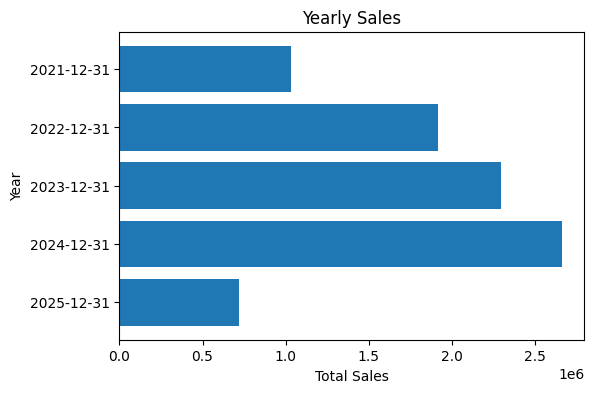

In [46]:
sales_year = dftv.groupby(pd.Grouper(key='date', freq='Y'))['sales'].sum().sort_index(ascending = False)
plt.figure(figsize=(6, 4))
plt.barh(sales_year.index.astype(str), sales_year.values)
plt.xlabel('Total Sales')
plt.ylabel('Year')
plt.title('Yearly Sales')
# plt.tight_layout()
plt.show()

In [47]:
top_20_models_sales = dftv.groupby('model')['sales'].sum().nlargest(20)

In [48]:
top_20_models_sales

model
NEXON            631100.0
CRETA            626200.0
VITARA BREZZA    618300.0
ERTIGA           585400.0
PUNCH            552800.0
VENUE            473500.0
SCORPIO          422000.0
BOLERO           371400.0
SELTOS           369400.0
SONET            349210.0
FRONX            301300.0
GRAND VITARA     296400.0
XUV 700          265100.0
XUV 300          263751.0
THAR             235100.0
CARENS           210775.0
S PRESSO         173620.0
XL6              158282.0
EXTER            148600.0
HYRYDER          132200.0
Name: sales, dtype: float64

In [49]:
top_20_models_sales.values

array([631100., 626200., 618300., 585400., 552800., 473500., 422000.,
       371400., 369400., 349210., 301300., 296400., 265100., 263751.,
       235100., 210775., 173620., 158282., 148600., 132200.])

In [50]:
top_20_models_sales.index.astype(str)

Index(['NEXON', 'CRETA', 'VITARA BREZZA', 'ERTIGA', 'PUNCH', 'VENUE',
       'SCORPIO', 'BOLERO', 'SELTOS', 'SONET', 'FRONX', 'GRAND VITARA',
       'XUV 700', 'XUV 300', 'THAR', 'CARENS', 'S PRESSO', 'XL6', 'EXTER',
       'HYRYDER'],
      dtype='object', name='model')

In [51]:
# saving the pandas series 'top_20_models_sales' as a csv file
top_20_models_sales.to_csv('top_20_models_sales.csv', index = True)

In [3]:
# after loading it from .csv file it becomes a dataframe
# in rder to convert it back to a pandas series we need to make use of squeeze() function
# squeeze fucntion will work if the dataframe contains only one column as in this case
top_20_models_sales = (pd.read_csv('top_20_models_sales.csv', index_col = 0)).squeeze()

In [53]:
top_20_models_sales.values

array([631100., 626200., 618300., 585400., 552800., 473500., 422000.,
       371400., 369400., 349210., 301300., 296400., 265100., 263751.,
       235100., 210775., 173620., 158282., 148600., 132200.])

In [54]:
top_20_models_sales.index.astype(str)

Index(['NEXON', 'CRETA', 'VITARA BREZZA', 'ERTIGA', 'PUNCH', 'VENUE',
       'SCORPIO', 'BOLERO', 'SELTOS', 'SONET', 'FRONX', 'GRAND VITARA',
       'XUV 700', 'XUV 300', 'THAR', 'CARENS', 'S PRESSO', 'XL6', 'EXTER',
       'HYRYDER'],
      dtype='object', name='model')

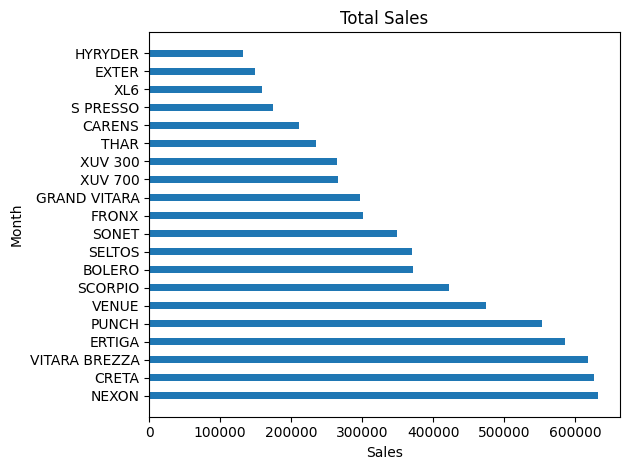

In [55]:
plt.figure()
plt.barh(top_20_models_sales.index.astype(str), top_20_models_sales.values, height = 0.4)
plt.xlabel('Sales')
plt.ylabel('Month')
plt.title('Total Sales')
plt.tight_layout()
plt.show()